<a href="https://colab.research.google.com/github/Flavio-98/cdProjetoAplicadoIV/blob/master/projeto/cd_projeto_aplicado_IV_etapa_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

  <img src="https://raw.githubusercontent.com/scalabrinig/cdProjetoAplicadoIV/d093146488f56dfcf0ef286bcee8efe0e71b9c76/figuras/mackenzie_logo.jpg" width="25%" align="right"/>

# **PROJETO APLICADO IV - Ciência de Dados EaD - 2026/01**


# **Entrega 2**

---

# **Titulo do Projeto**: Análise Preditiva e Modelagem de Séries Temporais: Tarifas Aéreas Domésticas (ANAC 2022-2025)

---

In [ ]:
#@title **Identificação do Grupo e Opção do Projeto**

#@title **Identificação do Grupo e Opção do Projeto**

#@markdown Integrantes do Grupo, nome completo em ordem alfabética (*informe: <nome>, <matrícula>*)
Aluno1 = 'Flavio Estevam Nogueira Andrade, 10441572' #@param {type:"string"}
Aluno2 = 'Kaique Nascimento de Paula, 24024831' #@param {type:"string"}
Aluno3 = 'Miguel Shiraishi, 10431805' #@param {type:"string"}
Aluno4 = 'Moacyr Souza Barros, 10441179' #@param {type:"string"}



# **1 Introdução**

**1.1 Contexto**

O setor aéreo brasileiro é dominado por três grandes empresas: Azul, Gol e Latam. Após o período crítico da pandemia, o mercado passou por uma fase de reorganização, enfrentando mudanças na demanda dos passageiros e custos operacionais variados. Para entender como o setor está hoje, a ANAC (Agência Nacional de Aviação Civil) disponibiliza microdados detalhados sobre todas as tarifas comercializadas no país. Para a realização deste projeto, foram utilizados microdados tarifários brutos extraídos do portal oficial da ANAC. A base completa, composta pelos arquivos CSV consolidados para a análise, está armazenada e disponível para conferência através do seguinte link: https://drive.google.com/drive/folders/1BoLlqGzr8HVCwM1OV2yucq2RszoV8vvh?usp=drive_link

**1.2 Motivação**

A principal motivação deste trabalho é aplicar as técnicas de Ciência de Dados aprendidas no curso para transformar uma base de dados bruta e volumosa em informações visuais. Observar como o equilíbrio de forças entre as três principais companhias aéreas do país e como isso reflete no custo do consumidor. Analisar esses dados permite identificar padrões que não são óbvios apenas lendo notícias ou sites de vendas.

**1.3 Objetivos**

**1.3.1 Objetivo Geral**
Analisar o comportamento do mercado de aviação civil nacional entre os anos de 2022 e 2025, focando na participação de mercado e na evolução dos preços das passagens das três principais companhias aéreas.

**1.3.2 Objetivos Específicos**

- Tratamento de Dados: Utilizar a biblioteca Pandas para filtrar e limpar a base de dados da ANAC, focando apenas nos voos domésticos das empresas alvo.

- Análise de Market Share: Calcular e visualizar a fatia de mercado de cada companhia através de gráficos de setores (pizza).

- Análise Temporal: Gerar gráficos de linha para acompanhar a variação mensal do preço médio das passagens, identificando tendências e sazonalidade.

- Comparação de Performance: Confrontar os dados das três empresas para entender qual delas manteve maior estabilidade de preços e volume de vendas no período.

**1.4 Justificativa**

Este projeto se justifica pela necessidade de monitorar a concentração de mercado em um setor essencial para a economia brasileira. Com a saída de empresas menores e os desafios financeiros das grandes companhias, entender como o market share se distribui e como os preços reagem é fundamental para a análise econômica do setor. Tecnicamente, o projeto justifica-se pelo desafio de manipular grandes volumes de dados provenientes da ANAC, exigindo o uso eficiente de bibliotecas de processamento de dados em Python, como o Pandas, para gerar insights que ferramentas comuns de escritório não suportariam com facilidade.

In [ ]:
from google.colab import drive
import pandas as pd
import zipfile
import os
import matplotlib.pyplot as plt
from statsmodels.tsa.seasonal import seasonal_decompose
from statsmodels.tsa.stattools import adfuller

drive.mount('/content/gdrive')

Mounted at /content/gdrive


# **Referencial Teórico**

O foco central deste trabalho é a análise do comportamento dos preços das passagens aéreas, um indicador fundamental para entender a acessibilidade do transporte aéreo e as estratégias das companhias aéreas. O conceito principal envolve o monitoramento da tarifa aérea média doméstica, que reflete as variações de custo conforme a sazonalidade, a demanda e a concorrência entre as empresas (ANAC, 2024). Ao discutir trabalhos correlacionados, nota-se que estudos do setor costumam focar em indicadores macroeconômicos ou relatórios anuais consolidados, muitas vezes utilizando ferramentas de Business Intelligence (BI) ou planilhas eletrônicas como o Excel para o tratamento dos dados. Embora o uso de planilhas seja uma alternativa comum para problemas semelhantes, essa abordagem apresenta limitações críticas de performance e escalabilidade ao processar o volume massivo de microdados tarifários disponibilizados pela ANAC. Em contrapartida, a solução proposta utiliza a linguagem Python e a biblioteca Pandas, oferecendo a vantagem de automatizar o pipeline de limpeza e permitir uma análise temporal granular e precisa. Além do foco nos preços, utiliza-se o conceito de Market Share como uma variável secundária para observar se a concentração de mercado entre as três principais operadoras influencia diretamente na flutuação das tarifas praticadas (MCKINNEY, 2022). Dessa forma, o projeto utiliza técnicas modernas de Ciência de Dados para superar as restrições de ferramentas manuais, garantindo maior reprodutibilidade e profundidade na análise do mercado aéreo.

# **Pipeline da Solução**

O pipeline da solução proposta foi estruturado para garantir a eficiência no processamento do grande volume de microdados tarifários da ANAC. O fluxo se divide em cinco etapas principais:

- Ingestão e Carregamento: Os dados são importados diretamente para o ambiente de desenvolvimento (Google Colab). Devido ao tamanho dos arquivos, utiliza-se a biblioteca Pandas para a leitura otimizada dos CSVs, garantindo que a memória seja utilizada de forma equilibrada.

- Filtragem e Seleção: Nesta etapa, o conjunto de dados é reduzido para focar apenas nos voos domésticos realizados pelas empresas Azul, Gol e Latam entre os anos de 2022 e 2025. Isso elimina ruídos e dados irrelevantes para o objetivo do projeto.

- Pré-processamento e Limpeza: Aqui é feita a padronização dos tipos de dados, como a conversão de datas e valores monetários. Também são tratados valores nulos e removidos registros duplicados ou inconsistentes que possam enviesar a média de preços.

- Processamento e Agrupamento: Os dados são agrupados por mês e por companhia aérea para o cálculo das métricas principais: o preço médio da passagem e o volume de vendas necessário para determinar a participação de mercado.

- Análise Visual e Insights: Na etapa final, as bibliotecas Matplotlib e Seaborn são utilizadas para gerar visualizações gráficas (gráficos de linha para séries temporais e de pizza para market share), permitindo a interpretação final sobre o comportamento dos preços no período analisado.

In [ ]:
import os
from google.colab import drive

if not os.path.exists('/content/gdrive'):
    drive.mount('/content/gdrive')

caminho_drive = '/content/gdrive/My Drive/Projeto4/'

zips = sorted([f for f in os.listdir(caminho_drive) if f.endswith('.zip')])

print(f"✅ Sucesso! Encontrados {len(zips)} arquivos para processar.")

✅ Sucesso! Encontrados 4 arquivos para processar.


In [ ]:
def processar_mes(df_temp):
    mapeamento = {
        'Ano de Referência': 'ano', 'ANO': 'ano', 'nr_ano_referencia': 'ano',
        'Mês de Referência': 'mes', 'MES': 'mes', 'nr_mes_referencia': 'mes',
        'Tarifa-N': 'preco', 'TARIFA': 'preco', 'nr_tarifa': 'preco',
        'Assentos Comercializados': 'qtd', 'ASSENTOS': 'qtd', 'nr_assentos': 'qtd'
    }

    df_temp = df_temp.rename(columns=mapeamento)
    cols_foco = ['ano', 'mes', 'preco', 'qtd']

    existentes = [c for c in cols_foco if c in df_temp.columns]
    df_temp = df_temp[existentes].copy()

    if df_temp['preco'].dtype == 'object':
        df_temp['preco'] = pd.to_numeric(df_temp['preco'].str.replace(',', '.'), errors='coerce')

    df_temp = df_temp.dropna(subset=['preco', 'qtd'])

    df_temp['faturamento_estimado'] = df_temp['preco'] * df_temp['qtd']

    resumo = df_temp.groupby(['ano', 'mes']).agg({
        'faturamento_estimado': 'sum',
        'qtd': 'sum'
    }).reset_index()

    resumo['tarifa_media'] = resumo['faturamento_estimado'] / resumo['qtd']
    return resumo[['ano', 'mes', 'tarifa_media']]

lista_series = []

for z_file in zips:
    path_full = os.path.join(caminho_drive, z_file)
    with zipfile.ZipFile(path_full, 'r') as z:
        for csv in [n for n in z.namelist() if n.lower().endswith('.csv')]:
            with z.open(csv) as f:
                df_mes = pd.read_csv(f, sep=';', encoding='latin1')
                lista_series.append(processar_mes(df_mes))
                print(f"✅ Processado: {csv}")

df_final = pd.concat(lista_series).sort_values(['ano', 'mes'])
df_final['data'] = pd.to_datetime(df_final['ano'].astype(int).astype(str) + '-' +
                                df_final['mes'].astype(int).astype(str) + '-01')

print("\n--- BASE DE SÉRIE TEMPORAL CONCLUÍDA ---")
df_final.head()

✅ Processado: 202201.CSV
✅ Processado: 202202.CSV
✅ Processado: 202203.CSV
✅ Processado: 202204.CSV
✅ Processado: 202205.CSV
✅ Processado: 202206.CSV
✅ Processado: 202207.CSV
✅ Processado: 202208.CSV
✅ Processado: 202209.CSV
✅ Processado: 202210.CSV
✅ Processado: 202211.CSV
✅ Processado: 202212.CSV
✅ Processado: 202501.CSV
✅ Processado: 202502.CSV
✅ Processado: 202503.CSV
✅ Processado: 202504.CSV
✅ Processado: 202505.CSV
✅ Processado: 202506.CSV
✅ Processado: 202507.CSV
✅ Processado: 202508.CSV
✅ Processado: 202509.CSV
✅ Processado: 202510.CSV
✅ Processado: 202511.CSV
✅ Processado: 202512.CSV
✅ Processado: 202301.CSV
✅ Processado: 202302.CSV
✅ Processado: 202303.CSV
✅ Processado: 202304.CSV
✅ Processado: 202305.CSV
✅ Processado: 202306.CSV
✅ Processado: 202307.CSV
✅ Processado: 202308.CSV
✅ Processado: 202309.CSV
✅ Processado: 202310.CSV
✅ Processado: 202311.CSV
✅ Processado: 202312.CSV
✅ Processado: 202401.CSV
✅ Processado: 202402.CSV
✅ Processado: 202403.CSV
✅ Processado: 202404.CSV


,ano,mes,tarifa_media,data
0,2022,1,478.342227,2022-01-01
0,2022,2,492.654479,2022-02-01
0,2022,3,648.287898,2022-03-01
0,2022,4,659.202491,2022-04-01
0,2022,5,682.596113,2022-05-01


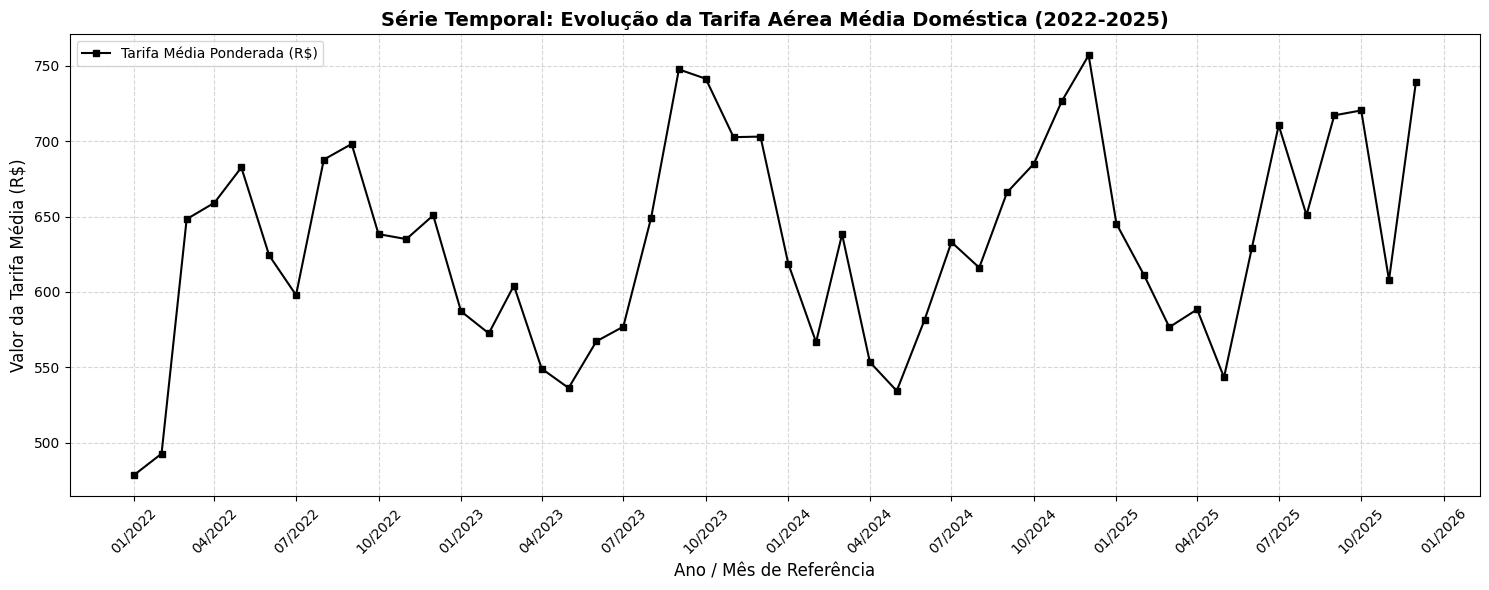

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(15, 6))

plt.plot(df_final['data'], df_final['tarifa_media'],
         color='black', linewidth=1.5, marker='s', markersize=4,
         label='Tarifa Média Ponderada (R$)')

plt.title('Série Temporal: Evolução da Tarifa Aérea Média Doméstica (2022-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Ano / Mês de Referência', fontsize=12)
plt.ylabel('Valor da Tarifa Média (R$)', fontsize=12)

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.MonthLocator(interval=3))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))

plt.grid(True, which='both', linestyle='--', alpha=0.5)
plt.xticks(rotation=45)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()

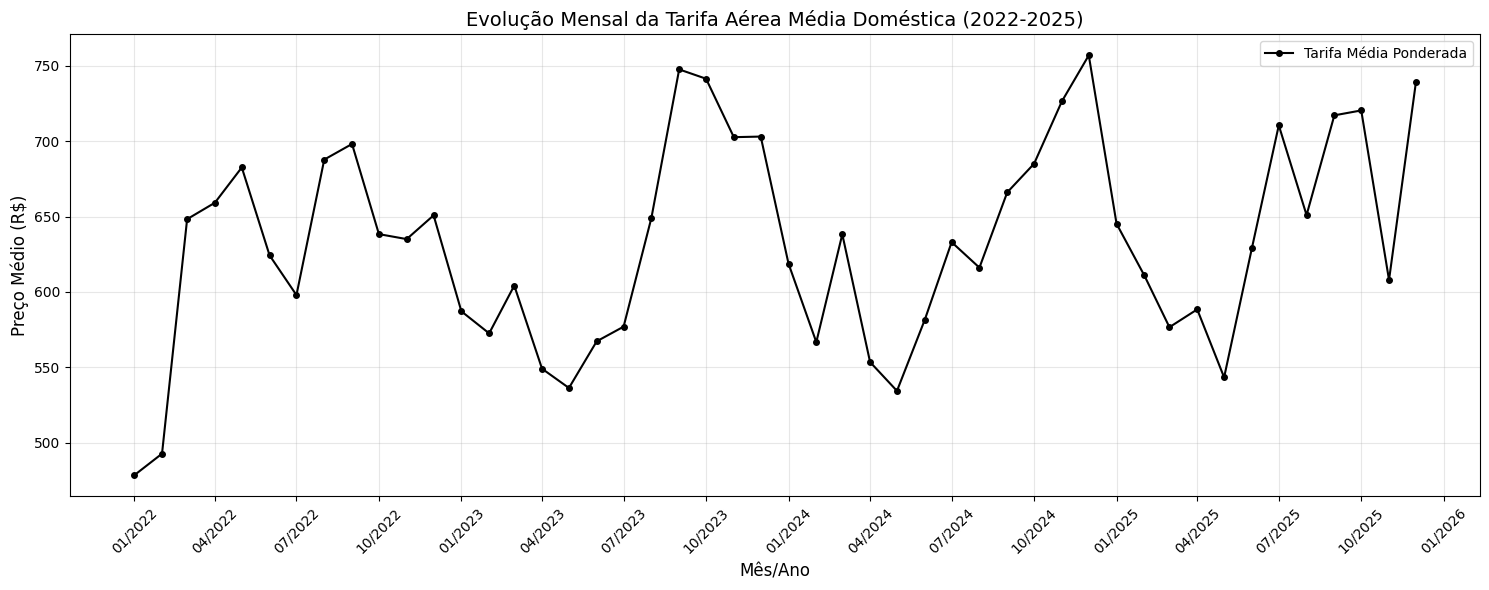

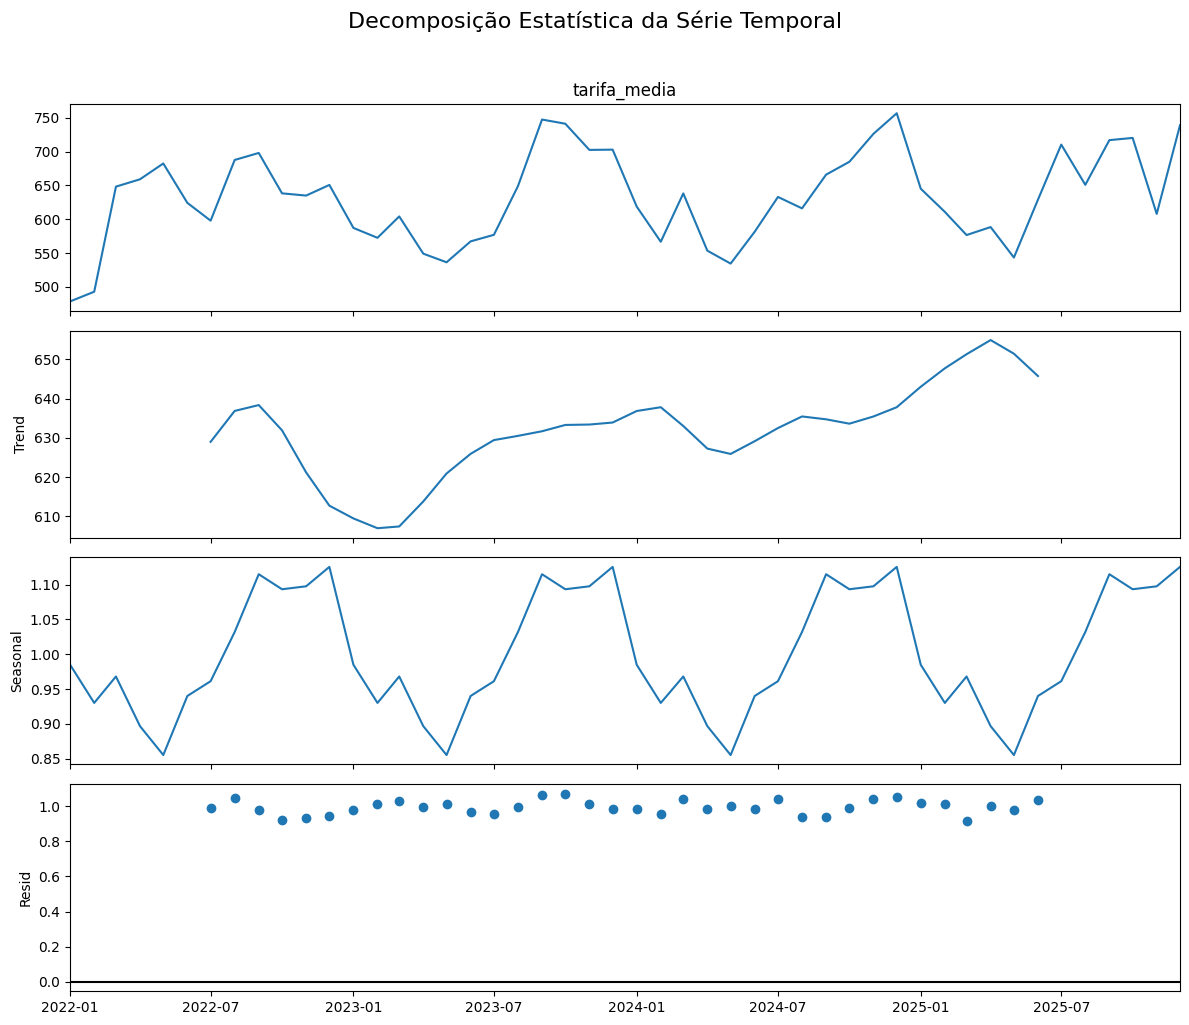

In [ ]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from statsmodels.tsa.seasonal import seasonal_decompose

plt.figure(figsize=(15, 6))
plt.plot(df_final['data'], df_final['tarifa_media'], color='black',
         marker='o', markersize=4, linestyle='-', linewidth=1.5, label='Tarifa Média Ponderada')

plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m/%Y'))
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.xticks(rotation=45)

plt.title('Evolução Mensal da Tarifa Aérea Média Doméstica (2022-2025)', fontsize=14)
plt.xlabel('Mês/Ano', fontsize=12)
plt.ylabel('Preço Médio (R$)', fontsize=12)
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

df_decomp = df_final.set_index('data')
analise_fina = seasonal_decompose(df_decomp['tarifa_media'], model='multiplicative', period=12)

fig = analise_fina.plot()
fig.set_size_inches(12, 10)
plt.suptitle('Decomposição Estatística da Série Temporal', fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# **Cronograma**

| Etapa | Data Limite | Atividades Principais | Status |
| :--- | :--- | :--- | :--- |
| **Etapa 1** | 01/03 | Definição do tema e organização do GitHub. | Concluído |
| **Etapa 2** | 29/03 | Ingestão, Pipeline e EDA (26M registros). | Concluído |
| **Etapa 3** | 26/04 | Implementação de modelos (SARIMA/LSTM). | Em Aberto |
| **Etapa 4** | 31/05 | Análise crítica e Entrega final. | Em Aberto |

# **Referências**
AGÊNCIA NACIONAL DE AVIAÇÃO CIVIL (ANAC). **Microdados de Tarifas Aéreas Comercializadas**. Brasília, DF: ANAC, 2024. Disponível em: https://www.gov.br/anac/pt-br/assuntos/dados-e-estatisticas/microdados-de-tarifas-aereas-comercializadas. Acesso em: 15 abr. 2026.

HUNTER, J. D. **Matplotlib: A 2D graphics environment**. Computing in Science & Engineering, v. 9, n. 3, p. 90-95, 2007.

MCKINNEY, W. **Python for Data Analysis: Data Wrangling with Pandas, NumPy, and IPython**. 3. ed. Sebastopol: O'Reilly Media, 2022.

PANDAS DEVELOPMENT TEAM. **pandas-dev/pandas: Pandas 2.2.0**. Zenodo, 2024. Disponível em: https://pandas.pydata.org. Acesso em: 15 abr. 2026.

WASKOM, M. L. **Seaborn: statistical data visualization**. Journal of Open Source Software, v. 5, n. 52, p. 2121, 2020.

In [ ]:
#@title **Avaliação**
Referencial_teorico = 10 #@param {type:"slider", min:0, max:10, step:1}

Pipeline_solucao = 10 #@param {type:"slider", min:0, max:10, step:1}

Cronograma = 10 #@param {type:"slider", min:0, max:10, step:1}

In [ ]:
#@title **Nota Final**
nota = 0.45*Referencial_teorico + 0.45*Pipeline_solucao + 0.10*Cronograma

print(f'Nota final do trabalho {nota :.1f}')

import numpy as np
import pandas as pd

alunos = pd.DataFrame()

lista_nome = []

for i in range(1,6):
  exec("if Aluno" + str(i) + " !='None':  lista = Aluno" + str(i) + ".split(','); lista_nome.append(lista[0]);")

alunos['nome'] = lista_nome
alunos['nota'] = np.round(nota,1)
print()
display(alunos)

Nota final do trabalho 10.0



,nome,nota
0,Aluno 1,10.0
1,Aluno 2,10.0
2,Aluno 3,10.0
3,Aluno 4,10.0
4,Aluno 5,10.0
